# True Chi-elevation profile with x scaling to RP-1 outlet

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from TopoAnalysis import dem as d

area loaded
fd loaded
elevation loaded
Calculating chi from main outlet (RP-1)...
Chi calculated for entire network
Processing RP-S2...
  Data points: 980
  Chi range: 172.8 - 4369.5 m
  Elevation range: 21.0 - 195.0 m

Processing RP-S3...
  Data points: 4986
  Chi range: 101.6 - 5780.8 m
  Elevation range: 20.0 - 337.0 m

Processing RP-S3u...
  Data points: 2521
  Chi range: 988.5 - 5780.8 m
  Elevation range: 211.0 - 327.0 m

Processing RP-S4u...
  Data points: 233
  Chi range: 1636.8 - 4476.4 m
  Elevation range: 165.0 - 281.0 m

Saved: chi_elevation_unified_scale_individual.png


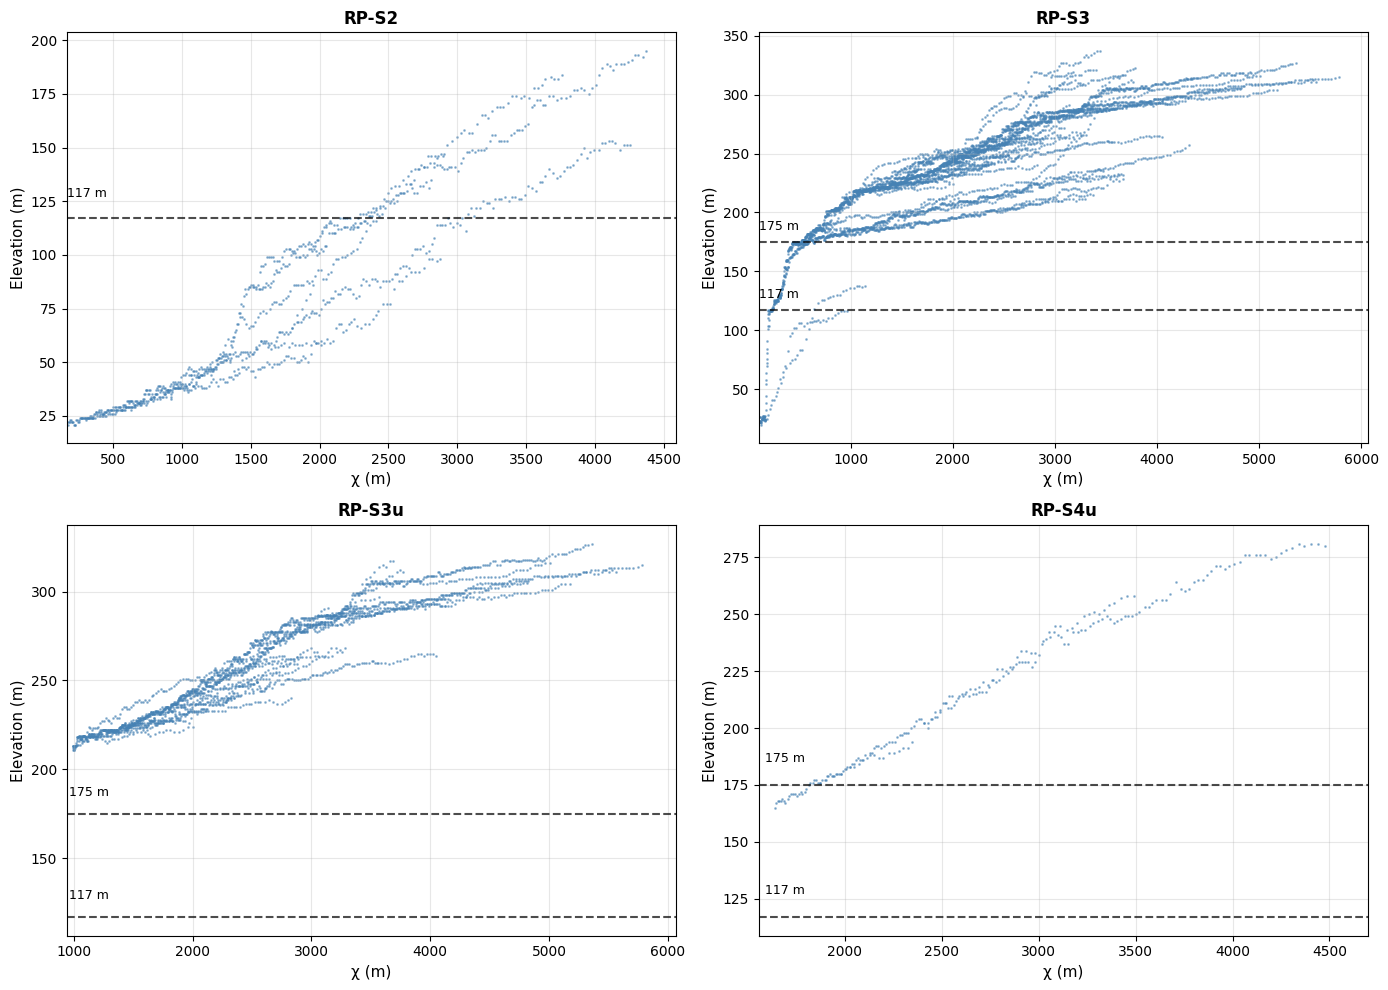

Saved: chi_elevation_unified_overlay.png


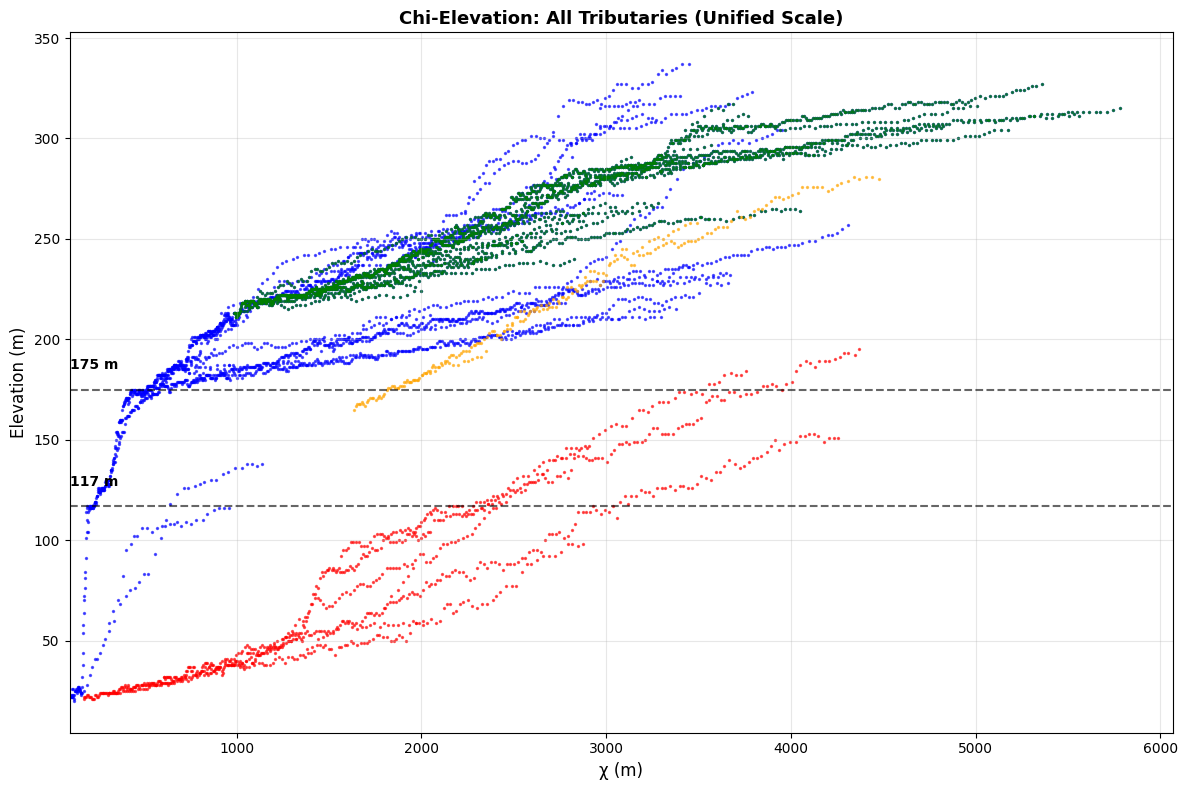


Done! All tributaries plotted with knickpoint markers.
Overall chi range across all tributaries: 101.6 - 5780.8 m

Knickpoints marked:
  RP-S2: [117] m elevation
  RP-S3: [117, 175] m elevation
  RP-S3u: [117, 175] m elevation
  RP-S4u: [117, 175] m elevation


In [4]:
"""
Chi-elevation plots for each tributary sample WITH KNICKPOINT MARKERS
- Chi calculated from MAIN outlet (RP-1) so all on same scale
- X-axis limited to actual data extent (not 0)
- Each tributary starts at its actual chi value (not 0)
- Black dotted knickpoint lines with labels
"""

# Main river outlet (RP-1) - reference for all chi calculations
main_outlet = (240012.37420, 6244480.71900)

# Sample locations (where you collected samples)
sample_locations = {
    'RP-S2': (246249.2076, 6240448.447),
    'RP-S3': (250212.9354, 6237948.848),
    'RP-S3u': (250603.5211, 6228481.157),
    'RP-S4u': (262281.9748, 6217862.614)
}

# Knickpoint elevations (from your work)
# These are the elevations where knickpoints occur
knickpoints = {
    'RP-S2': [117],  # m elevation
    'RP-S3': [117, 175],  # m elevation - you found two knickpoints
    'RP-S3u': [117, 175],  # m elevation
    'RP-S4u': [117, 175]  # m elevation
}

# Load data once
area = d.Area.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_area_utm30m')
print('area loaded')
fd = d.FlowDirectionD8.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_fd_utm30m')
print('fd loaded')
elevation = d.Elevation.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_SRTMGL130m_dem_utm.tif')
print('elevation loaded')

# Calculate chi ONCE using main outlet
print("Calculating chi from main outlet (RP-1)...")
chi_main = d.Chi(flow_direction=fd, area=area, theta=0.55, Ao=1e6, outlets=[main_outlet])
print("Chi calculated for entire network")

# Get full grids
chi_data_full = chi_main._griddata
elev_data_full = elevation._griddata
area_data_full = area._griddata

# Track overall limits for consistent plotting
overall_chi_min = np.inf
overall_chi_max = 0

# For each sample, create a watershed mask and plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sample_data = {}

for idx, (sample, sample_point) in enumerate(sample_locations.items()):
    print(f"Processing {sample}...")
    
    # Calculate chi treating this sample point as outlet
    chi_sample = d.Chi(flow_direction=fd, area=area, theta=0.55, Ao=1e6, outlets=[sample_point])
    chi_sample_data = chi_sample._griddata
    
    # Create mask: pixels that are in this sample's watershed (chi_sample > 0)
    # AND have area >= 1 km^2
    mask_watershed = chi_sample_data > 0
    mask_area = area_data_full >= 1e6
    mask_combined = mask_watershed & mask_area
    
    # Extract chi and elevation for this watershed using MAIN outlet chi values
    chi_masked = chi_data_full[mask_combined]
    elev_masked = elev_data_full[mask_combined]
    
    # Remove NaNs
    valid = ~np.isnan(chi_masked) & ~np.isnan(elev_masked)
    chi_masked = chi_masked[valid]
    elev_masked = elev_masked[valid]
    
    # Track min/max for this watershed
    chi_min = chi_masked.min()
    chi_max = chi_masked.max()
    overall_chi_min = min(overall_chi_min, chi_min)
    overall_chi_max = max(overall_chi_max, chi_max)
    
    # Store for later
    sample_data[sample] = {
        'chi': chi_masked,
        'elev': elev_masked,
        'chi_min': chi_min,
        'chi_max': chi_max
    }
    
    print(f"  Data points: {len(chi_masked)}")
    print(f"  Chi range: {chi_min:.1f} - {chi_max:.1f} m")
    print(f"  Elevation range: {elev_masked.min():.1f} - {elev_masked.max():.1f} m\n")
    
    # Plot on subplot with data-limited x-axis
    ax = axes[idx]
    ax.scatter(chi_masked, elev_masked, s=1, alpha=0.5, c='steelblue')
    ax.set_xlabel('χ (m)', fontsize=11)
    ax.set_ylabel('Elevation (m)', fontsize=11)
    ax.set_title(f'{sample}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # X-axis limited to actual data range for THIS watershed
    ax.set_xlim(chi_min * 0.95, chi_max * 1.05)
    
    # Add knickpoint markers (vertical black dotted lines)
    if sample in knickpoints:
        for kp_elev in knickpoints[sample]:
            ax.axhline(kp_elev, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.text(chi_min * 0.97, kp_elev + 10, f'{kp_elev} m', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('Figures/chi_elevation_unified_scale_individual.png', dpi=150, bbox_inches='tight')
print("Saved: chi_elevation_unified_scale_individual.png")
plt.show()

# Create overlay comparison plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange']

for (sample, color) in zip(sample_locations.keys(), colors):
    chi_masked = sample_data[sample]['chi']
    elev_masked = sample_data[sample]['elev']
    
    ax.scatter(chi_masked, elev_masked, s=2, alpha=0.6, label=sample, c=color)

# Add knickpoint markers to overlay plot
# Show all knickpoint elevations as horizontal black dotted lines
all_knickpoint_elevs = set()
for sample in knickpoints:
    for kp_elev in knickpoints[sample]:
        all_knickpoint_elevs.add(kp_elev)

for kp_elev in sorted(all_knickpoint_elevs):
    ax.axhline(kp_elev, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label=f'KP {kp_elev} m' if kp_elev == sorted(all_knickpoint_elevs)[0] else '')
    ax.text(overall_chi_min * 0.98, kp_elev + 10, f'{kp_elev} m', fontsize=10, color='black', fontweight='bold')

ax.set_xlabel('χ (m)', fontsize=12)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.set_title('Chi-Elevation: All Tributaries (Unified Scale)', fontsize=13, fontweight='bold')
#ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
# X-axis limited to overall data extent across all watersheds
ax.set_xlim(overall_chi_min * 0.95, overall_chi_max * 1.05)

plt.tight_layout()
plt.savefig('Figures/chi_elevation_unified_overlay.png', dpi=150, bbox_inches='tight')
print("Saved: chi_elevation_unified_overlay.png")
plt.show()

print("\nDone! All tributaries plotted with knickpoint markers.")
print(f"Overall chi range across all tributaries: {overall_chi_min:.1f} - {overall_chi_max:.1f} m")
print(f"\nKnickpoints marked:")
for sample, kps in knickpoints.items():
    print(f"  {sample}: {kps} m elevation")

